In [1]:
from PIL import Image
import torch
import numpy as np
import json
import huggingface_hub

from modeling.BaseModel import BaseModel
from modeling import build_model
from utilities.distributed import init_distributed
from utilities.arguments import load_opt_from_config_files
from utilities.constants import BIOMED_CLASSES


from inference_utils.inference import interactive_infer_image, interactive_infer_image_all
from inference_utils.output_processing import check_mask_stats
# P-value (adjusted) that the segmentation belongs to "nodule" in the CT-Chest class
# Lower p-value indicates it is likely the segmentation not belongs to the class. Recommended threshold is 0.05

C:\Users\Toni\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


Deformable Transformer Encoder is not available.


C:\Users\Toni\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\kornia\feature\lightglue.py:30: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)


In [5]:
with open('tokens.json') as f:
    tokens = json.load(f)

In [6]:
HF_TOKEN = tokens['hugging_face']

huggingface_hub.login(HF_TOKEN)

### Model Setup

In [2]:
# Build model config
opt = load_opt_from_config_files(["configs/biomedparse_inference.yaml"])
opt = init_distributed(opt)

# Load model from pretrained weights
pretrained_pth = 'pretrained\\biomedparse_v1.pt'

# pretrained_pth = 'hf_hub:microsoft/BiomedParse'

model = BaseModel(opt, build_model(opt)).from_pretrained(pretrained_pth).eval().cuda()
with torch.no_grad():
    model.model.sem_seg_head.predictor.lang_encoder.get_text_embeddings(BIOMED_CLASSES + ["background"], is_eval=True)

C:\Users\Toni\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\huggingface_hub\file_download.py:795: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
$UNUSED$ criterion.empty_weight, Ckpt Shape: torch.Size([17])


### Utility Functions

In [3]:
def plot_segmentation_masks(original_image, segmentation_masks, texts, rotate=0):
    ''' Plot a list of segmentation mask over an image.
    '''
    original_image = original_image[:, :, :3]
    fig, ax = plt.subplots(1, len(segmentation_masks) + 1, figsize=(10, 5))
    ax[0].imshow(np.rot90(original_image, rotate), cmap='gray')
    ax[0].set_title('Original Image')
    # grid off
    for a in ax:
        a.axis('off')

    for i, mask in enumerate(segmentation_masks):
        
        ax[i+1].set_title(texts[i])
        mask_temp = original_image.copy()
        mask_temp[mask > 0.5] = [255, 0, 0]
        mask_temp[mask <= 0.5] = [0, 0, 0, ]
        ax[i+1].imshow(np.rot90(mask_temp, rotate), alpha=0.9)
        ax[i+1].imshow(np.rot90(original_image, rotate), cmap='gray', alpha=0.5)
        
    
    plt.show()

In [4]:
!pip install pydicom nibabel SimpleITK

import json
import matplotlib.pyplot as plt

from inference_utils.processing_utils import read_nifti , read_nifti_only, read_rgb


def inference_nifti(file_path, text_prompts, is_CT, slice_idx, site=None, HW_index=(0, 1), channel_idx=None, rotate=0):
    image = read_nifti(file_path, is_CT, slice_idx, site=site, 
                       HW_index=HW_index, channel_idx=channel_idx)
    
    pred_mask = interactive_infer_image(model, Image.fromarray(image), text_prompts)

    # Plot feature over image
    plot_segmentation_masks(image, pred_mask, text_prompts, rotate=rotate)
    
    return image, pred_mask



[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: C:\Users\Toni\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
def inference_recognition(file_path, is_CT, slice_idx, site, image_type, p_value_threshold=None, HW_index=(0, 1), channel_idx=None):
    image = read_nifti(file_path, is_CT, slice_idx, site=site, 
                       HW_index=HW_index, channel_idx=channel_idx)

    
    predictions = interactive_infer_image_all(model, Image.fromarray(image), image_type, p_value_threshold)
    targets = list(predictions.keys())
    pred_mask = [predictions[t] for t in targets]
    # Plot feature over image
    plot_segmentation_masks(image, pred_mask, targets)
    
    return image, pred_mask, targets


### Ultrasound Example

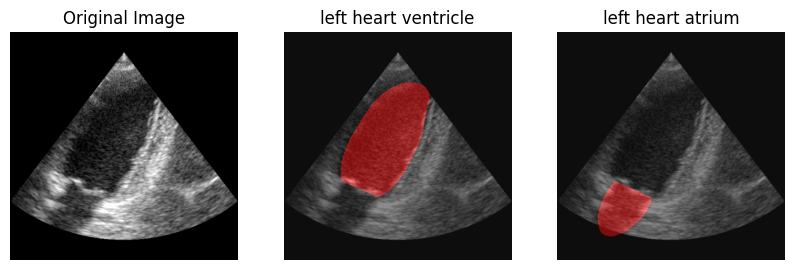

left heart ventricle P-value: 0.3717138202503065
left heart atrium P-value: 0.4223427242323042


In [7]:
image_path = 'examples/patient0500_2CH_half_sequence.nii.gz'
text_prompt = ['left heart ventricle', 'left heart atrium']
slide_idx = 0

image, pred_mask = inference_nifti(image_path, text_prompt, is_CT=False, slice_idx=slide_idx, site=None, rotate=3)

for i in range(len(pred_mask)):
    adj_pvalue = check_mask_stats(image, pred_mask[i]*255, 'Ultrasound-Cardiac', text_prompt[i])
    print(f'{text_prompt[i]} P-value: {adj_pvalue}')

### MRI Example
#### T1-Gd

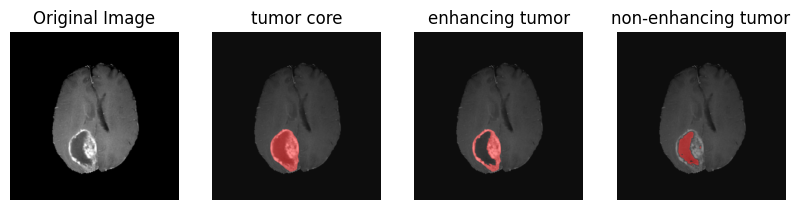

tumor core P-value: 0.3022350794112916
enhancing tumor P-value: 0.5358968595455798
non-enhancing tumor P-value: 0.07102385628651892


In [11]:
image_path = 'examples/BRATS_397.nii.gz'
text_prompt = ['tumor core', 'enhancing tumor', 'non-enhancing tumor']
slide_idx = 89

image, pred_mask =  inference_nifti(image_path, text_prompt, is_CT=False, slice_idx=slide_idx, site=None, channel_idx=2, rotate=1)

for i in range(len(pred_mask)):
    adj_pvalue = check_mask_stats(image, pred_mask[i]*255, 'MRI-T1-Gd-Brain', text_prompt[i])
    print(f'{text_prompt[i]} P-value: {adj_pvalue}')

#### FLAIR

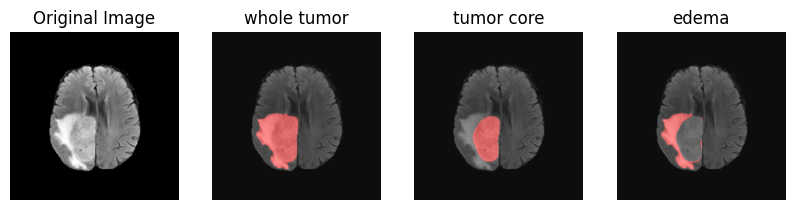

whole tumor P-value: 0.2934591381007444
tumor core P-value: 0.4401112952701697
edema P-value: 0.316755534409188


In [84]:
image_path = 'examples/BRATS_422.nii.gz'
text_prompt = ['whole tumor', 'tumor core', 'edema']
slide_idx = 84

image, pred_mask =  inference_nifti(image_path, text_prompt, is_CT=False, slice_idx=slide_idx, site=None, channel_idx=0, rotate=1)

for i in range(len(pred_mask)):
    adj_pvalue = check_mask_stats(image, pred_mask[i]*255, 'MRI-FLAIR-Brain', text_prompt[i])
    print(f'{text_prompt[i]} P-value: {adj_pvalue}')

### CT Example

In [18]:
image_path = 'data\CT\img\\100005_00001_0000.nii.gz'

img, nii = read_nifti_only(image_path)

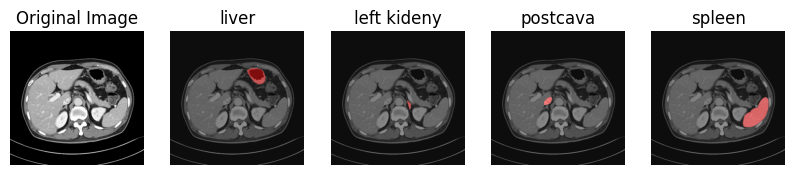

In [6]:
# image_path = 'test2.nii.gz'
image_path = 'data\CT\img\\100033_00001_0000.nii.gz'


image_path = 'examples/amos_0328.nii.gz'
text_prompt = ['liver', 'left kideny', 'postcava', 'spleen']
slide_idx = 68

image, pred_mask = inference_nifti(image_path, text_prompt, is_CT=True, slice_idx=slide_idx, site='abdomen', rotate=1)

# for i in range(len(pred_mask)):
#     adj_pvalue = check_mask_stats(image, pred_mask[i]*255, 'CT-Abdomen', text_prompt[i])
#     print(f'{text_prompt[i]} P-value: {adj_pvalue}')

In [ ]:
labels = {'tumor': 1, 'aorta': 2, 'right kidney': 3, 'left kidney': 4, 'duodenum': 5, 'pancreas': 6, 'liver':7, 'spleen':8, 'stomach':9, 'gallbladder':10, 'left adrenal gland':11, 'right adrenal gland':12, 'esophagus':13, 'postcava': 14}

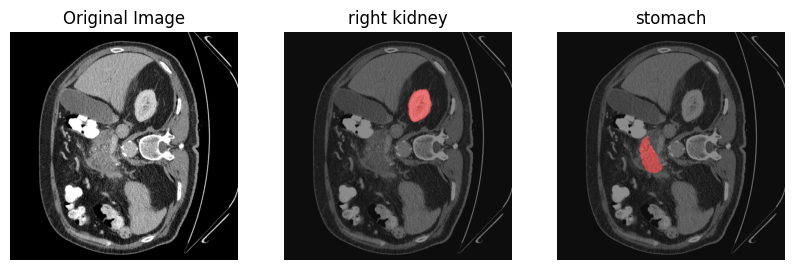

In [36]:
image_path = 'data\CT\img\\100082_00001_0000.nii.gz'
# image_path = 'test2.nii.gz'
# image_path = 'examples/amos_0328.nii.gz'
# text_prompt = ['find all organs']
slide_idx = 350
image, pred_mask, target = inference_recognition(image_path, True, slide_idx, 'abdomen', 'CT-Abdomen', None)


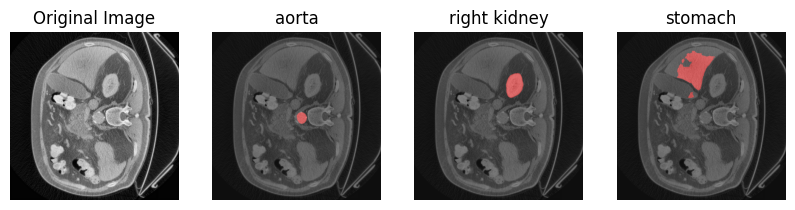

In [38]:
image_path = 'test2.nii.gz'
# image_path = 'examples/amos_0328.nii.gz'
# text_prompt = ['find all organs']
slide_idx = 350
image, pred_mask, target = inference_recognition(image_path, True, slide_idx, 'abdomen', 'CT-Abdomen', None)
